# Explorando um Pipeline de ETL com Python
---
## Desafio de Projeto - Módulo 01

* **Contexto**: Originalmente, o desafio de projeto compreendia o _consumo_ de uma API (_API da Santander Dev Week_) criada e disponibilizada para a atividade. Entretanto, tal API encontra-se indisponível no momento de exexução deste desafio. Considerando que o objetivo geral do desafio é o apresndizado do fluxo **ETL - _Extraction_ - (Extração), _Transformation_ (Transformação) e _Load_ (Carregamento)**, optou-se de utilizar outra API para desenvolvimento da atividade.  Nesse sentido, optou-se por utilizar uma das APIs disponibilizadas pela NASA: [_Fireball Data API_](https://ssd-api.jpl.nasa.gov/doc/fireball.html), que forneceregoistros dedados de impacto atmosférico da bólides relatados por sensores do governo dos EUA.

## Etapas do processo ETL

### 1. _Extract_ (Extração)

A **API Fireball** fornece dados de _fireballs_ (meteoros brilhantes) relatados pelos sensores do governo dos EUA.

* Fonte de Dados: https://ssd-api.jpl.nasa.gov/fireball.api
* Formato da Resposta: JSON
* Método HTTP: GET

In [1]:
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')



print(today)

2026-09-21


In [2]:
# Bibliotecas importadas
import json
import requests

# Função para extração dos dados
def get_data():
    url = f'https://ssd-api.jpl.nasa.gov/fireball.api'
    response = requests.get(url)
    data = response.json()

    return data


In [3]:
# Extração dos dados brutos e primeira visualização
dados = get_data()
print(json.dumps(dados, indent=2))


{
  "signature": {
    "source": "NASA/JPL Fireball Data API",
    "version": "1.2"
  },
  "count": "1073",
  "fields": [
    "date",
    "energy",
    "impact-e",
    "lat",
    "lat-dir",
    "lon",
    "lon-dir",
    "alt",
    "vel"
  ],
  "data": [
    [
      "2026-09-15 11:26:13",
      "2.2",
      "0.079",
      "37.6",
      "S",
      "161.6",
      "W",
      "37.0",
      null
    ],
    [
      "2026-09-11 10:18:03",
      "6.1",
      "0.2",
      "0.2",
      "S",
      "129.6",
      "W",
      "70.0",
      null
    ],
    [
      "2026-09-11 01:12:11",
      "24.6",
      "0.67",
      "54.4",
      "N",
      "100.1",
      "W",
      "38.0",
      null
    ],
    [
      "2026-09-10 05:22:22",
      "11.1",
      "0.33",
      "19.3",
      "S",
      "28.1",
      "W",
      "33.6",
      "19.3"
    ],
    [
      "2026-08-15 07:32:40",
      "3.9",
      "0.13",
      "4.0",
      "N",
      "115.4",
      "W",
      "37.0",
      null
    ],
    [
      "2026-08

A _API Firebal_ fornece como saída um único objeto JSON. Note que o campo `signiture` indica a fonte (`"source": "NASA?JPL Fireball Data API"`) e a versão da API (`"version": "1.2"`). Obtivemos um resultado com 1.073 registros (`"count": "1073`). Cada registro é fornecido como um elemento do `"data"` e os nomes de cada campo em cada registro podem ser encontrados no objeto `"fields"`. Conforme documentação da API, os campos dão definidos da seguinte forma:


|**Campo**        |**Descrição**                                            |
|:----------------|:--------------------------------------------------------|
|date             |data/hora do pico de brilho (GMT)                        |
|energy           |energia total irradiada aproximada ($10^{10}$ joules)    |
|impact-e         |energia de impacto total aproximada (kt)                 |
|lat              |latitude no brilho máximo (graus)                        |
|lat-dir          |direção de latitude (“N” ou “S”)                         |
|lon              |longitude no pico de brilho (graus)                      |
|lon-dir          |direção de latitude (“E” ou “W”)                         |
|alt              |altitude acima do geoide no pico de brilho (km)          |
|vel              |Velocidade de entrada (km/s)                             |


## 2. _Transform_ (Transformação)

Nesa fasa, ajustamos a estrutura bruta da API para uma tabela relacional usando `pandas`.

In [4]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    dados["data"],
    columns = dados["fields"]
)

df.head()

,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel
0,2026-09-15 11:26:13,2.2,0.079,37.6,S,161.6,W,37.0,NaN
1,2026-09-11 10:18:03,6.1,0.2,0.2,S,129.6,W,70.0,NaN
2,2026-09-11 01:12:11,24.6,0.67,54.4,N,100.1,W,38.0,NaN
3,2026-09-10 05:22:22,11.1,0.33,19.3,S,28.1,W,33.6,19.3
4,2026-08-15 07:32:40,3.9,0.13,4.0,N,115.4,W,37.0,NaN


2. Tratamento de Tipos de Dados

    Observemos os tipos de dados para correção posterior:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      1073 non-null   str  
 1   energy    1073 non-null   str  
 2   impact-e  1073 non-null   str  
 3   lat       887 non-null    str  
 4   lat-dir   887 non-null    str  
 5   lon       887 non-null    str  
 6   lon-dir   887 non-null    str  
 7   alt       601 non-null    str  
 8   vel       361 non-null    str  
dtypes: str(9)
memory usage: 75.6 KB


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['energy'] = pd.to_numeric(df['energy'], errors='coerce')
df['impact-e'] = pd.to_numeric(df['impact-e'], errors='coerce')
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['alt'] = pd.to_numeric(df['alt'], errors='coerce')
df['vel'] = pd.to_numeric(df['vel'], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      1073 non-null   datetime64[us]
 1   energy    1073 non-null   float64       
 2   impact-e  1073 non-null   float64       
 3   lat       887 non-null    float64       
 4   lat-dir   887 non-null    str           
 5   lon       887 non-null    float64       
 6   lon-dir   887 non-null    str           
 7   alt       601 non-null    float64       
 8   vel       361 non-null    float64       
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 75.6 KB


3. Conversão e Padronização de Coordenadas (Latitude/Longitude): A API fornece a direção em colunas separadas (`lat-dir` sendo N/S e `lon-dir` sendo E/W). Regra de transformação:
   * Se `lat-dir`=='S', multiplicar `lat`por -1;
   * Se `lon-dir`=='W', multiplicar `lon`por -1. 

In [7]:
df['lat'] = np.where(df['lat-dir']=='S', -df['lat'], df['lat'])
df['lon'] = np.where(df['lon-dir']=='S', -df['lon'], df['lon'])

df.sample(10)

,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel
773,2004-12-11 15:36:51,3.00,0.100,36.0,N,104.1,E,NaN,NaN
912,2000-07-19 17:40:25,10.70,0.320,-17.7,S,94.1,E,NaN,NaN
836,2003-04-13 17:58:41,17.50,0.500,14.8,N,64.5,E,17.0,NaN
788,2004-07-03 20:47:22,6.50,0.210,NaN,NaN,NaN,NaN,NaN,NaN
792,2004-06-04 13:41:38,33.90,0.890,NaN,NaN,NaN,NaN,NaN,NaN
53,2025-02-02 16:30:50,4.00,0.130,-17.7,S,24.3,E,40.0,NaN
826,2003-07-21 05:11:28,5.80,0.190,NaN,NaN,NaN,NaN,NaN,NaN
224,2020-04-14 11:11:16,2.00,0.073,-65.6,S,45.6,W,NaN,NaN
175,2021-10-20 08:41:50,5.91,0.190,13.8,N,140.4,W,28.0,NaN
905,2000-09-24 06:57:19,2.70,0.095,NaN,NaN,NaN,NaN,NaN,NaN


4. Criação de colunas derivadas para ano e ano-mês

In [8]:
df['year'] = df['date'].dt.year

df['year-month'] = df['date'].dt.to_period('M')

df.head()

,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel,year,year-month
0,2026-09-15 11:26:13,2.2,0.079,-37.6,S,161.6,W,37.0,NaN,2026,2026-09
1,2026-09-11 10:18:03,6.1,0.200,-0.2,S,129.6,W,70.0,NaN,2026,2026-09
2,2026-09-11 01:12:11,24.6,0.670,54.4,N,100.1,W,38.0,NaN,2026,2026-09
3,2026-09-10 05:22:22,11.1,0.330,-19.3,S,28.1,W,33.6,19.3,2026,2026-09
4,2026-08-15 07:32:40,3.9,0.130,4.0,N,115.4,W,37.0,NaN,2026,2026-08


5. Valores faltantes: Após pesquisa acerca do contexto da análise de dados astronômicos, optou-se por manter valores faltantes (`NaN/Null`) nas variáveis altitude (`alt`) e velocidade (`vel`) a fim de preservar a integridade científica dos dados e evitar a introdução de viés por imputação arbitrárias. 

### 3. _Load_ (Carregamento)

Finalizamos o processo de ETL com o carregamento dos dados para o formato CSV para análises posteriores.

In [9]:
import os

data_inicio = df['date'].min().strftime('%Y-%m-%d')
data_fim = df['date'].max().strftime('%Y-%m-%d')

nome_arquivo = f'fireballs_{data_inicio}_{data_fim}.csv'
diretorio_destino = "./data/output"

os.makedirs(diretorio_destino, exist_ok=True)
caminho_completo = os.path.join(diretorio_destino, nome_arquivo)

df.to_csv(caminho_completo, index=False, encoding='utf-8')

## Análises Exploratórias e Estatísticas

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/output/fireballs_1988-04-15_2026-09-15.csv')
df.head()

,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel,year,year-month
0,2026-09-15 11:26:13,2.2,0.079,-37.6,S,161.6,W,37.0,NaN,2026,2026-09
1,2026-09-11 10:18:03,6.1,0.200,-0.2,S,129.6,W,70.0,NaN,2026,2026-09
2,2026-09-11 01:12:11,24.6,0.670,54.4,N,100.1,W,38.0,NaN,2026,2026-09
3,2026-09-10 05:22:22,11.1,0.330,-19.3,S,28.1,W,33.6,19.3,2026,2026-09
4,2026-08-15 07:32:40,3.9,0.130,4.0,N,115.4,W,37.0,NaN,2026,2026-08


1. Resumo estatístico geral

In [11]:
df.describe()

,energy,impact-e,lat,lon,alt,vel,year
count,1073.000000,1073.000000,887.000000,887.000000,601.000000,361.000000,1073.000000
mean,67.690932,1.125282,-1.475310,90.219053,36.878536,18.840443,2010.915191
std,1153.900341,13.687557,37.617186,52.160022,11.219000,7.170222,9.042359
min,1.240000,0.048000,-85.000000,0.100000,14.000000,9.800000,1988.000000
25%,3.200000,0.110000,-31.050000,44.800000,29.600000,14.400000,2004.000000
50%,6.170000,0.200000,-1.000000,90.800000,35.200000,17.200000,2011.000000
75%,14.100000,0.410000,28.100000,135.050000,40.800000,21.000000,2019.000000
max,37500.000000,441.000000,88.500000,180.000000,90.500000,71.100000,2026.000000


2. Distribuição das propriedades físicas

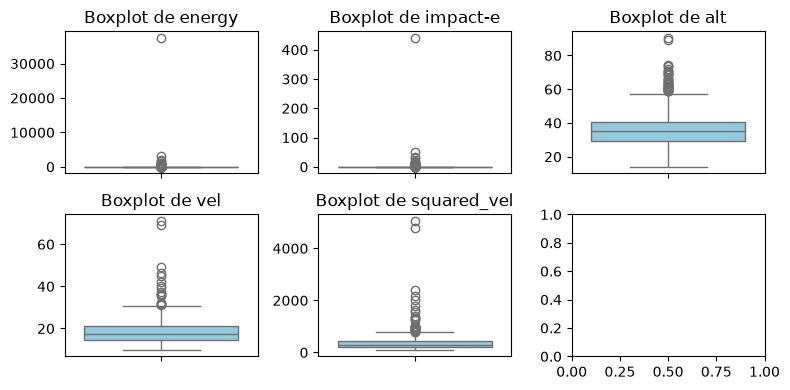

In [12]:
df['squared_vel'] = df['vel']**2

cols = ['energy', 'impact-e', 'alt', 'vel', 'squared_vel']

ncols = 3
nrows = int(np.ceil(len(cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 2 * nrows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('')



plt.tight_layout()
plt.show()

3. Remover _outliers_ de `energy`

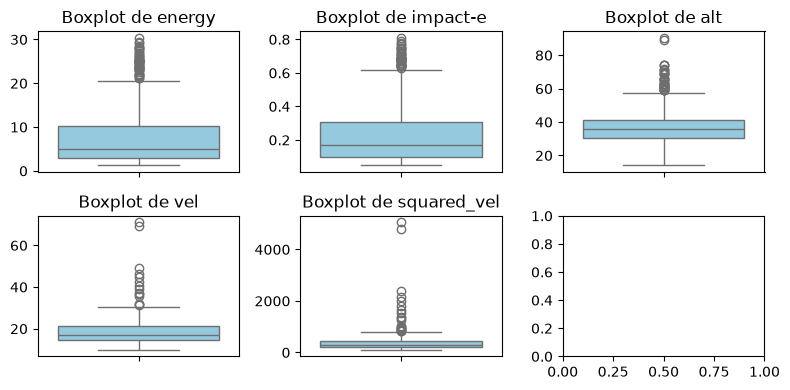

In [13]:
# Calcular os quartis Q1 e Q3
Q1 = df['energy'].quantile(0.25)
Q3 = df['energy'].quantile(0.75)

# Calcular o IQR
IQR = Q3 - Q1

# Definir os limites inferior e superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df[(df['energy'] < limite_inferior) | (df['energy'] > limite_superior)]

# Remover outliers
df = df[(df['energy'] >= limite_inferior) & (df['energy'] <= limite_superior)]


cols = ['energy', 'impact-e', 'alt', 'vel', 'squared_vel']

ncols = 3
nrows = int(np.ceil(len(cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 2 * nrows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('')



plt.tight_layout()
plt.show()
